In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
dataset = pd.read_csv('ogle2012blg0371.txt', sep=' ')

dataset = dataset.rename(columns={'2455260.86264' : 'hjd'})
dataset = dataset.rename(columns={'17.743' : 'I magnitude'})
dataset = dataset.rename(columns={'0.018' : 'Imagnitude_erro'})
dataset = dataset.rename(columns={'3.80' : 'mean_impact-parameter'})
dataset = dataset.rename(columns={'651.0' : 'i_dont_know'})

df = dataset[['hjd', 'I magnitude', 'Imagnitude_erro', 'mean_impact-parameter', 'i_dont_know']]

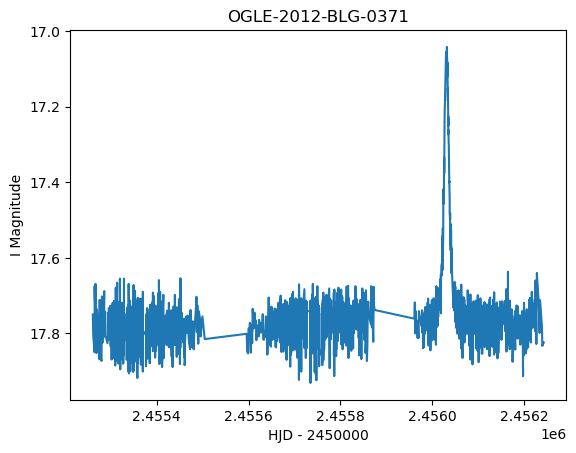

In [3]:
x = df['hjd']
y = df['I magnitude']

plt.title('OGLE-2012-BLG-0371')
plt.xlabel('HJD - 2450000')
plt.ylabel('I Magnitude')

# plt.axvline(x=6031.205, color='r', linestyle='--')

plt.plot(x, y)
plt.gca().invert_yaxis()

In [4]:
def parte_decimal(numero):
  return math.modf(numero/10000)[0]

df_clean = df.copy()

df_clean['hjd'] = df_clean['hjd'].apply(parte_decimal)

df_clean['hjd'] = round(df_clean['hjd']*10000, 2)
df_clean

,hjd,I magnitude,Imagnitude_erro,mean_impact-parameter,i_dont_know
0,5260.91,17.750,0.024,3.91,1539.0
1,5261.80,17.806,0.024,5.13,731.0
2,5264.82,17.850,0.023,4.72,621.0
3,5264.87,17.675,0.019,4.71,580.0
4,5264.89,17.692,0.018,4.28,594.0
...,...,...,...,...,...
4576,6233.52,17.799,0.029,7.04,600.0
4577,6234.51,17.712,0.024,5.55,763.0
4578,6238.51,17.780,0.029,5.55,832.0
4579,6239.51,17.833,0.027,6.13,688.0


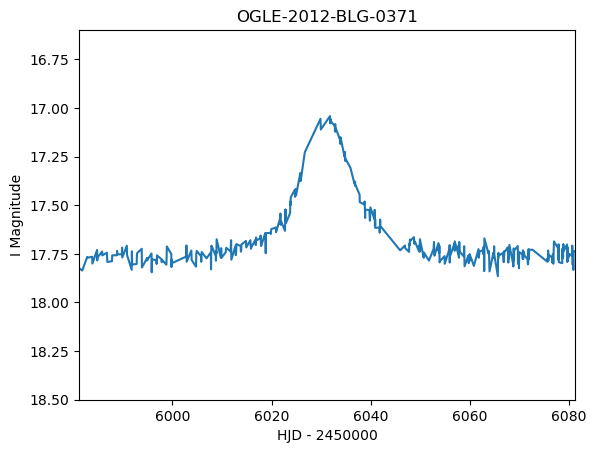

In [5]:
x = df_clean['hjd']
y = df_clean['I magnitude']


plt.title('OGLE-2012-BLG-0371')
plt.xlabel('HJD - 2450000')
plt.ylabel('I Magnitude')

limit = 50
plt.xlim(6031.205-limit, 6031.205+limit)
plt.ylim(16.6, 18.5)

plt.plot(x, y)
plt.gca().invert_yaxis()

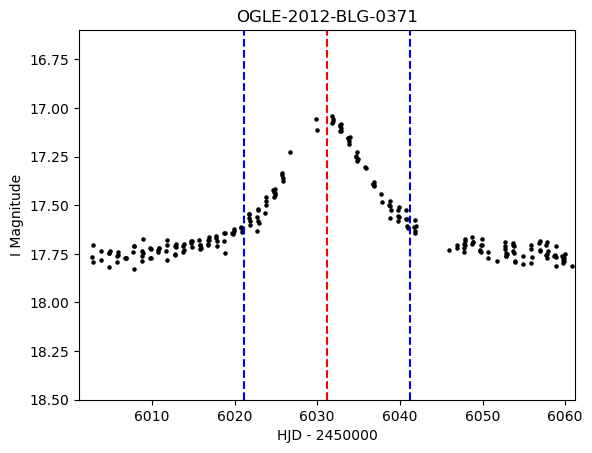

In [6]:
x = df_clean['hjd']
y = df_clean['I magnitude']

tau = 10.031

df_clean.plot.scatter(x='hjd', y='I magnitude', s = 5, c='k', marker='o', linewidths=1)
plt.axvline(x=6031.205, color='r', linestyle='--')
plt.axvline(x=6031.205 + tau, color='b', linestyle='--')
plt.axvline(x=6031.205 - tau, color='b', linestyle='--')

plt.title('OGLE-2012-BLG-0371')
plt.xlabel('HJD - 2450000')
plt.ylabel('I Magnitude')

limit = 30
plt.xlim(6031.205-limit, 6031.205+limit)
plt.ylim(16.6, 18.5)

plt.gca().invert_yaxis()
plt.show()

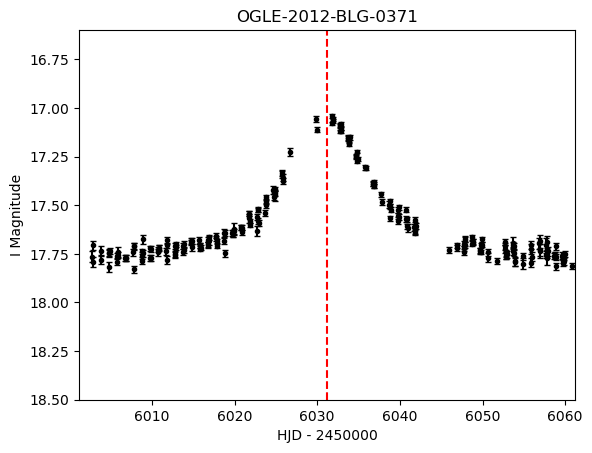

In [7]:
x = df_clean['hjd']
y = df_clean['I magnitude']
erros = df_clean['Imagnitude_erro']


df.plot.scatter(x='hjd', y='I magnitude', s = 5, c='k', marker='o', linewidths=1)
plt.axvline(x=6031.205, color='r', linestyle='--')

plt.errorbar(x, y, yerr=erros, fmt='.', capsize=2, label='Erro', c='k')

plt.title('OGLE-2012-BLG-0371')
plt.xlabel('HJD - 2450000')
plt.ylabel('I Magnitude')

limit = 30
plt.xlim(6031.205-limit, 6031.205+limit)
plt.ylim(16.6, 18.5)

plt.gca().invert_yaxis()
plt.show()

**plotando a Mts(s) pela Equação 2.38 para vários valores do "parametro de impacto"**

In [8]:
mu = 0.1
mu2 = 0.424
mu3 = 1

t0 = 6031.2
te = 10.03

du = (df_clean['hjd']-t0)/te

s = du.apply(lambda x: math.sqrt(mu**2 + x**2))
s2 = du.apply(lambda x: math.sqrt(mu2**2 + x**2))
s3 = du.apply(lambda x: math.sqrt(mu3**2 + x**2))

s = s.to_frame().rename(columns={'hjd' : 's'})
s2 = s2.to_frame().rename(columns={'hjd' : 's2'})
s3 = s3.to_frame().rename(columns={'hjd' : 's3'})

data = pd.concat([df_clean, s], axis=1)
data2 = pd.concat([df_clean, s2], axis=1)
data3 = pd.concat([df_clean, s3], axis=1)

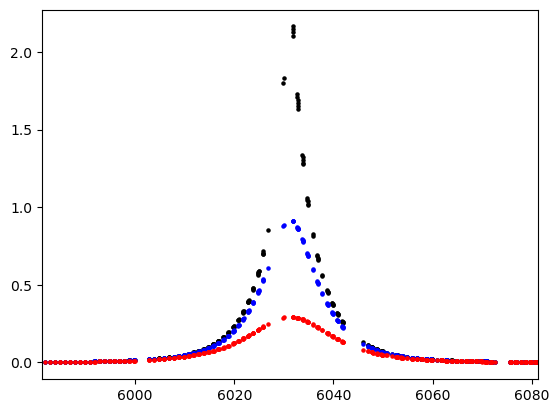

In [9]:
from sklearn.linear_model import LinearRegression

cima = data['s'].apply(lambda x: x*x + 2).to_frame().rename(columns={'s' : 'cima'})
cima2 = data2['s2'].apply(lambda x: x*x + 2).to_frame().rename(columns={'s2' : 'cima2'})
cima3 = data3['s3'].apply(lambda x: x*x + 2).to_frame().rename(columns={'s3' : 'cima3'})

baixo = data['s'].apply(lambda x: x*math.sqrt(x*x + 4)).to_frame().rename(columns={'s' : 'baixo'})
baixo2 = data2['s2'].apply(lambda x: x*math.sqrt(x*x + 4)).to_frame().rename(columns={'s2' : 'baixo2'})
baixo3 = data3['s3'].apply(lambda x: x*math.sqrt(x*x + 4)).to_frame().rename(columns={'s3' : 'baixo3'})

A = pd.DataFrame({'Mts' : cima['cima']/baixo['baixo']})
A2 = pd.DataFrame({'Mts2' : cima2['cima2']/baixo2['baixo2']})
A3 = pd.DataFrame({'Mts3' : cima3['cima3']/baixo3['baixo3']})

A = A['Mts'].apply(lambda x: math.log(x))
A2 = A2['Mts2'].apply(lambda x: math.log(x))
A3 = A3['Mts3'].apply(lambda x: math.log(x))

time = data['hjd']

dados = pd.concat([A, time], axis=1)
dados2 = pd.concat([A2, time], axis=1)
dados3 = pd.concat([A3, time], axis=1)

limit = 50
plt.xlim(6031.205-limit, 6031.205+limit)
# plt.ylim(math.log(16.6), math.log(18.5))

dados_completos = dados.merge(dados2, on='hjd').merge(dados3, on='hjd')

# # Plotar as três curvas no mesmo gráfico de dispersão
plt.scatter(dados_completos['hjd'], dados_completos['Mts'], c='k', s=5, marker='o', label='Mts')
plt.scatter(dados_completos['hjd'], dados_completos['Mts2'], c='b', s=5, marker='o', label='Mts2')
plt.scatter(dados_completos['hjd'], dados_completos['Mts3'], c='r', s=5, marker='o', label='Mts3')